## Classification using Decision Tree on Titanic Data

In [35]:
import seaborn as sns


# load data
df = sns.load_dataset('titanic')

# remove unwanted columns
df = df.drop(['embark_town', 'deck', 'class', 'alive', 'who'], axis=1)

# one hot encoding
df = pd.get_dummies(df, drop_first=True)

# removing outliers
df= df[df['age']>0]

X = df.drop('survived', axis=1)
y = df['survived']

In [36]:

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# model training
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

# model predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7902097902097902


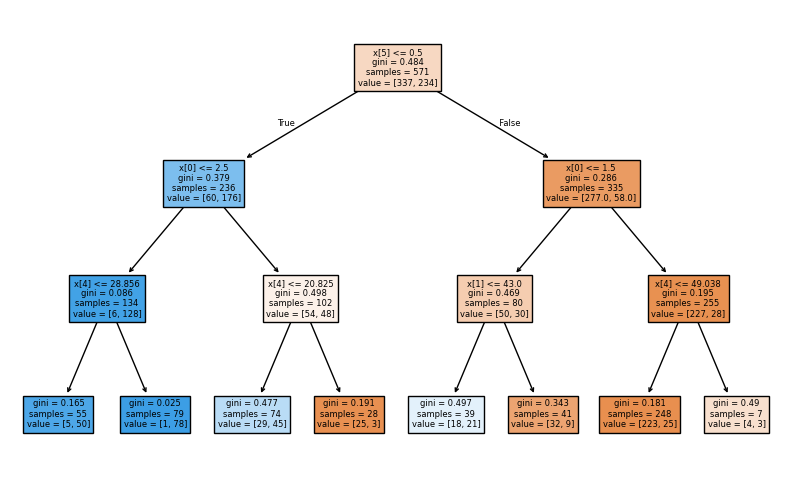

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# plot tree
plt.figure(figsize=(10,6))
plot_tree(model, filled=True)
plt.show()

## Regression using Decision Tree on Tips Data

In [60]:
import seaborn as sns

# load data
df = sns.load_dataset("tips")

# One Hot Encoding
df = pd.get_dummies(df,drop_first=True)

X = df.drop('total_bill', axis=1)
y = df['total_bill']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,r2_score

# training and predicting best parameters for model
for k in range(3,11):
    model = DecisionTreeRegressor(max_depth=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print(f"MSE {k}:", mean_squared_error(y_test, y_pred))
    print(f"r2_score {k}:", r2_score(y_test, y_pred))
    print()

MSE 3: 45.5950389423145
r2_score 3: 0.4622500066215778

MSE 4: 42.987848423344076
r2_score 4: 0.49299933191739387

MSE 5: 41.915789971617606
r2_score 5: 0.5056432387697722

MSE 6: 38.05830830412767
r2_score 6: 0.5511385555689204

MSE 7: 48.78561380061549
r2_score 7: 0.42462021950602324

MSE 8: 45.98034754433756
r2_score 8: 0.4577056591883254

MSE 9: 46.42446332936508
r2_score 9: 0.4524677371249195

MSE 10: 45.67312111337869
r2_score 10: 0.4613291018927571



In [66]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.9464078271976148
Test R2: 0.4613291018927571


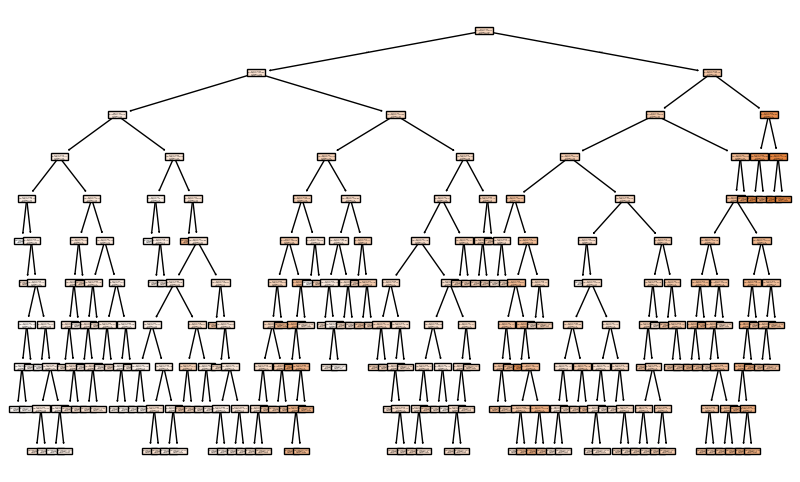

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# plot tree
plt.figure(figsize=(10,6))
plot_tree(model, filled=True)
plt.show()